In [76]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/mhamza76/wildfire-data/FW_Veg_Rem_Combined.csv
/kaggle/input/datasets/mhamza76/wildfire-data/Wildfire_att_description.txt


# Wildfire Severity Prediction
## U.S. Wildfire Data (1992–2015) | Clinical ML Portfolio Project

**Objective:** Predict whether a wildfire will be large (>=100 acres) or small
using satellite, weather, vegetation and geographic features.

**Dataset:** U.S. Wildfire data plus other attributes — 55,000 fire records

**Approach:** Data-driven feature selection using mutual information,
VIF redundancy removal, and SHAP-based importance. No manual feature picking.

**Models:** Logistic Regression, Random Forest, XGBoost, LightGBM

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, roc_curve, classification_report,
                             f1_score, brier_score_loss, average_precision_score,
                             precision_recall_curve, recall_score, precision_score)
from sklearn.calibration import calibration_curve
from sklearn.feature_selection import mutual_info_classif
from sklearn.impute import SimpleImputer
from statsmodels.stats.outliers_influence import variance_inflation_factor
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import shap

DATA_PATH = '/kaggle/input/datasets/mhamza76/wildfire-data/FW_Veg_Rem_Combined.csv'
print("Imports done")

Imports done


In [78]:
df = pd.read_csv(DATA_PATH)
print(f"Shape: {df.shape}")
print(f"\nColumns:\n{df.columns.tolist()}")
print(f"\nDtypes:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()[df.isnull().sum()>0]}")

Shape: (55367, 43)

Columns:
['Unnamed: 0.1', 'Unnamed: 0', 'fire_name', 'fire_size', 'fire_size_class', 'stat_cause_descr', 'latitude', 'longitude', 'state', 'disc_clean_date', 'cont_clean_date', 'discovery_month', 'disc_date_final', 'cont_date_final', 'putout_time', 'disc_date_pre', 'disc_pre_year', 'disc_pre_month', 'wstation_usaf', 'dstation_m', 'wstation_wban', 'wstation_byear', 'wstation_eyear', 'Vegetation', 'fire_mag', 'weather_file', 'Temp_pre_30', 'Temp_pre_15', 'Temp_pre_7', 'Temp_cont', 'Wind_pre_30', 'Wind_pre_15', 'Wind_pre_7', 'Wind_cont', 'Hum_pre_30', 'Hum_pre_15', 'Hum_pre_7', 'Hum_cont', 'Prec_pre_30', 'Prec_pre_15', 'Prec_pre_7', 'Prec_cont', 'remoteness']

Dtypes:
Unnamed: 0.1          int64
Unnamed: 0            int64
fire_name            object
fire_size           float64
fire_size_class      object
stat_cause_descr     object
latitude            float64
longitude           float64
state                object
disc_clean_date      object
cont_clean_date      objec

Label distribution:
large_fire
0    36522
1    18845
Name: count, dtype: int64

Large fire rate: 34.0%


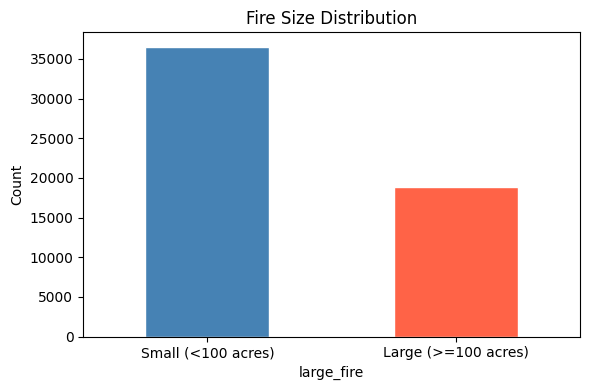


Columns remaining after dropping leakage: 33
['stat_cause_descr', 'latitude', 'longitude', 'state', 'disc_clean_date', 'discovery_month', 'disc_date_pre', 'disc_pre_year', 'disc_pre_month', 'wstation_usaf', 'dstation_m', 'wstation_wban', 'wstation_byear', 'wstation_eyear', 'Vegetation', 'weather_file', 'Temp_pre_30', 'Temp_pre_15', 'Temp_pre_7', 'Temp_cont', 'Wind_pre_30', 'Wind_pre_15', 'Wind_pre_7', 'Wind_cont', 'Hum_pre_30', 'Hum_pre_15', 'Hum_pre_7', 'Hum_cont', 'Prec_pre_30', 'Prec_pre_15', 'Prec_pre_7', 'Prec_cont', 'remoteness']


In [79]:
# Drop rows where label is missing
df = df.dropna(subset=['fire_size_class'])

# Create binary label
df['large_fire'] = df['fire_size_class'].apply(
    lambda x: 0 if x in ['A', 'B'] else 1
)

print("Label distribution:")
print(df['large_fire'].value_counts())
print(f"\nLarge fire rate: {df['large_fire'].mean():.1%}")

# Plot
fig, ax = plt.subplots(figsize=(6, 4))
df['large_fire'].value_counts().plot(kind='bar', ax=ax,
    color=['steelblue','tomato'], edgecolor='white')
ax.set_xticklabels(['Small (<100 acres)', 'Large (>=100 acres)'], rotation=0)
ax.set_title('Fire Size Distribution')
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig('fire_distribution.png', dpi=150)
plt.show()


DROP_COLS = [
    'fire_size',        # IS 
    'fire_size_class',  # IS the label — direct leakage
    'large_fire',       # IS the label
    'fire_mag',         # derived fr
    'putout_time',      # only known af
    'cont_clean_date',  # 
    'cont_date_final',  # cont
    'disc_date_final',  # too correlated 
    'objectid',         # row I
    'fod_id',           # row ID
    'fire_name',        # free text
    'shape',            # geometry
    'Unnamed: 0',       # index
    'Unnamed: 0.1'      # index
]

drop_existing = [c for c in DROP_COLS if c in df.columns]
features_df = df.drop(columns=drop_existing)

print(f"\nColumns remaining after dropping leakage: {features_df.shape[1]}")
print(features_df.columns.tolist())

In [80]:
y = df['large_fire'].copy()

# Identify categorical columns
cat_cols = features_df.select_dtypes(include=['object']).columns.tolist()
num_cols = features_df.select_dtypes(include=['number']).columns.tolist()

print(f"Categorical columns ({len(cat_cols)}): {cat_cols}")
print(f"Numeric columns ({len(num_cols)}): {num_cols}")

# Label encode categoricals
le = LabelEncoder()
for col in cat_cols:
    features_df[col] = features_df[col].astype(str)
    features_df[col] = le.fit_transform(features_df[col])

print("\nAll columns now numeric.")
print(f"Feature matrix shape: {features_df.shape}")

Categorical columns (8): ['stat_cause_descr', 'state', 'disc_clean_date', 'discovery_month', 'disc_date_pre', 'disc_pre_month', 'wstation_usaf', 'weather_file']
Numeric columns (25): ['latitude', 'longitude', 'disc_pre_year', 'dstation_m', 'wstation_wban', 'wstation_byear', 'wstation_eyear', 'Vegetation', 'Temp_pre_30', 'Temp_pre_15', 'Temp_pre_7', 'Temp_cont', 'Wind_pre_30', 'Wind_pre_15', 'Wind_pre_7', 'Wind_cont', 'Hum_pre_30', 'Hum_pre_15', 'Hum_pre_7', 'Hum_cont', 'Prec_pre_30', 'Prec_pre_15', 'Prec_pre_7', 'Prec_cont', 'remoteness']

All columns now numeric.
Feature matrix shape: (55367, 33)


In [81]:
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(
    imputer.fit_transform(features_df),
    columns=features_df.columns
)

print(f"Missing before: {features_df.isnull().sum().sum()}")
print(f"Missing after:  {X_imputed.isnull().sum().sum()}")
print(f"Feature matrix: {X_imputed.shape}")

Missing before: 0
Missing after:  0
Feature matrix: (55367, 33)


In [82]:
# Clean column names — remove special characters LightGBM does not allow
X_imputed.columns = (X_imputed.columns
                     .str.replace(r'[^\w]', '_', regex=True)
                     .str.replace(r'_+', '_', regex=True)
                     .str.strip('_'))

print("Cleaned column names:")
print(X_imputed.columns.tolist())

Cleaned column names:
['stat_cause_descr', 'latitude', 'longitude', 'state', 'disc_clean_date', 'discovery_month', 'disc_date_pre', 'disc_pre_year', 'disc_pre_month', 'wstation_usaf', 'dstation_m', 'wstation_wban', 'wstation_byear', 'wstation_eyear', 'Vegetation', 'weather_file', 'Temp_pre_30', 'Temp_pre_15', 'Temp_pre_7', 'Temp_cont', 'Wind_pre_30', 'Wind_pre_15', 'Wind_pre_7', 'Wind_cont', 'Hum_pre_30', 'Hum_pre_15', 'Hum_pre_7', 'Hum_cont', 'Prec_pre_30', 'Prec_pre_15', 'Prec_pre_7', 'Prec_cont', 'remoteness']


Computing mutual information scores...

Mutual Information Scores (top 20):
         feature  mi_score
   wstation_usaf  0.086449
    weather_file  0.079910
           state  0.064362
       longitude  0.062531
   wstation_wban  0.055637
stat_cause_descr  0.043644
   disc_date_pre  0.040048
 disc_clean_date  0.038180
      remoteness  0.036166
        latitude  0.034750
      Hum_pre_30  0.028903
        Hum_cont  0.027358
      Hum_pre_15  0.026789
       Hum_pre_7  0.024049
     Temp_pre_15  0.016367
       Temp_cont  0.016016
      dstation_m  0.015945
       Wind_cont  0.015883
      Wind_pre_7  0.015781
     Temp_pre_30  0.014715

Features passing MI threshold (0.01): 26


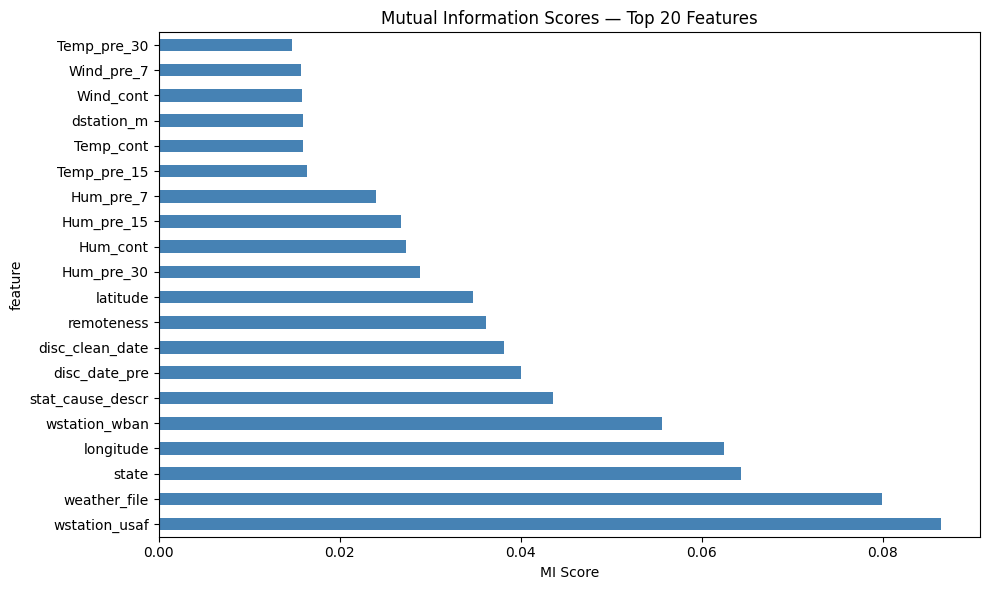

In [83]:
print("Computing mutual information scores...")
mi_scores = mutual_info_classif(X_imputed, y, random_state=42)
mi_df = pd.DataFrame({
    'feature': X_imputed.columns,
    'mi_score': mi_scores
}).sort_values('mi_score', ascending=False)

print("\nMutual Information Scores (top 20):")
print(mi_df.head(20).to_string(index=False))


MI_THRESHOLD = 0.01
mi_selected = mi_df[mi_df['mi_score'] >= MI_THRESHOLD]['feature'].tolist()
print(f"\nFeatures passing MI threshold ({MI_THRESHOLD}): {len(mi_selected)}")


fig, ax = plt.subplots(figsize=(10, 6))
mi_df.head(20).plot(kind='barh', x='feature', y='mi_score', ax=ax,
                     color='steelblue', legend=False)
ax.set_title('Mutual Information Scores — Top 20 Features')
ax.set_xlabel('MI Score')
plt.tight_layout()
plt.savefig('mutual_information.png', dpi=150)
plt.show()

In [84]:
print("Computing VIF scores to remove redundant features...")

X_mi = X_imputed[mi_selected].copy()

def compute_vif(X):
    vif_data = pd.DataFrame()
    vif_data['feature'] = X.columns
    vif_data['VIF'] = [variance_inflation_factor(X.values, i)
                       for i in range(X.shape[1])]
    return vif_data.sort_values('VIF', ascending=False)


X_vif = X_mi.copy()
while True:
    vif = compute_vif(X_vif)
    max_vif = vif['VIF'].max()
    if max_vif <= 10:
        break
    worst = vif.iloc[0]['feature']
    print(f"  Removing {worst} (VIF={max_vif:.1f})")
    X_vif = X_vif.drop(columns=[worst])

print(f"\nFeatures after VIF removal: {X_vif.shape[1]}")
print("Remaining features:", X_vif.columns.tolist())

vif_final = compute_vif(X_vif)
print("\nFinal VIF scores:")
print(vif_final.to_string(index=False))

Computing VIF scores to remove redundant features...
  Removing Temp_pre_15 (VIF=120.5)
  Removing longitude (VIF=91.8)
  Removing Hum_pre_15 (VIF=82.0)
  Removing Wind_pre_15 (VIF=49.6)
  Removing latitude (VIF=32.1)
  Removing Temp_pre_7 (VIF=29.7)
  Removing Hum_pre_30 (VIF=24.9)
  Removing weather_file (VIF=16.4)
  Removing Wind_pre_30 (VIF=15.8)
  Removing disc_clean_date (VIF=10.4)

Features after VIF removal: 16
Remaining features: ['wstation_usaf', 'state', 'wstation_wban', 'stat_cause_descr', 'disc_date_pre', 'remoteness', 'Hum_cont', 'Hum_pre_7', 'Temp_cont', 'dstation_m', 'Wind_cont', 'Wind_pre_7', 'Temp_pre_30', 'disc_pre_month', 'Prec_pre_30', 'discovery_month']

Final VIF scores:
         feature      VIF
        Hum_cont 9.526660
       Hum_pre_7 9.475166
       Temp_cont 8.987194
       Wind_cont 8.010936
      Wind_pre_7 7.451189
     Temp_pre_30 7.049520
   disc_date_pre 6.650688
   wstation_usaf 4.063344
      remoteness 3.933454
  disc_pre_month 3.702893
      dstat

In [85]:
print("Running baseline LightGBM for SHAP feature confirmation...")

X_tr_tmp, X_te_tmp, y_tr_tmp, y_te_tmp = train_test_split(
    X_vif, y, test_size=0.2, random_state=42, stratify=y
)

base_model = LGBMClassifier(n_estimators=100, random_state=42, verbose=-1)
base_model.fit(X_tr_tmp, y_tr_tmp)

explainer_base = shap.TreeExplainer(base_model)
shap_values_base = explainer_base.shap_values(X_te_tmp)

if isinstance(shap_values_base, list):
    sv_base = shap_values_base[1]
elif shap_values_base.ndim == 3:
    sv_base = shap_values_base[:, :, 1]
else:
    sv_base = shap_values_base


shap_importance = pd.DataFrame({
    'feature': X_vif.columns,
    'mean_abs_shap': np.abs(sv_base).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)

print("\nSHAP Importance (baseline):")
print(shap_importance.to_string(index=False))


SHAP_THRESHOLD = 0.001
shap_selected = shap_importance[
    shap_importance['mean_abs_shap'] >= SHAP_THRESHOLD
]['feature'].tolist()

print(f"\nFeatures passing SHAP threshold: {len(shap_selected)}")
FINAL_FEATURES = shap_selected
print("FINAL FEATURE SET:", FINAL_FEATURES)

Running baseline LightGBM for SHAP feature confirmation...

SHAP Importance (baseline):
         feature  mean_abs_shap
      remoteness       0.333444
stat_cause_descr       0.299572
           state       0.232787
      dstation_m       0.154916
       Wind_cont       0.124471
       Temp_cont       0.093459
       Hum_pre_7       0.093175
   wstation_usaf       0.089997
        Hum_cont       0.086006
   disc_date_pre       0.082495
   wstation_wban       0.051932
     Prec_pre_30       0.038271
     Temp_pre_30       0.028988
  disc_pre_month       0.024311
      Wind_pre_7       0.020185
 discovery_month       0.010344

Features passing SHAP threshold: 16
FINAL FEATURE SET: ['remoteness', 'stat_cause_descr', 'state', 'dstation_m', 'Wind_cont', 'Temp_cont', 'Hum_pre_7', 'wstation_usaf', 'Hum_cont', 'disc_date_pre', 'wstation_wban', 'Prec_pre_30', 'Temp_pre_30', 'disc_pre_month', 'Wind_pre_7', 'discovery_month']


In [86]:
X_final = X_vif[FINAL_FEATURES]

X_train, X_test, y_train, y_test = train_test_split(
    X_final, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {len(X_train)} | Test: {len(X_test)}")
print(f"Train large fire rate: {y_train.mean():.2f}")
print(f"Test large fire rate:  {y_test.mean():.2f}")
print(f"Final features used: {X_final.shape[1]}")

Train: 44293 | Test: 11074
Train large fire rate: 0.34
Test large fire rate:  0.34
Final features used: 16


In [87]:
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

model_grid = {
    'Logistic Regression': (
        LogisticRegression(class_weight='balanced',
                           max_iter=2000, random_state=42),
        {'C': [0.01, 0.1, 1, 10]}
    ),
    'Random Forest': (
        RandomForestClassifier(class_weight='balanced', random_state=42),
        {'n_estimators': [100, 200], 'max_depth': [5, 10, None]}
    ),
    'XGBoost': (
        XGBClassifier(scale_pos_weight=pos_weight, random_state=42,
                      eval_metric='logloss'),
        {'n_estimators': [100, 200], 'max_depth': [3, 5],
         'learning_rate': [0.05, 0.1]}
    ),
    'LightGBM': (
        LGBMClassifier(class_weight='balanced', random_state=42, verbose=-1),
        {'n_estimators': [100, 200], 'max_depth': [3, 5],
         'learning_rate': [0.05, 0.1]}
    )
}

tuned_models = {}
print("Grid Search + Stratified 5-Fold CV:\n")
for name, (model, params) in model_grid.items():
    gs = GridSearchCV(model, params, cv=skf,
                      scoring='roc_auc', n_jobs=-1)
    gs.fit(X_train, y_train)
    tuned_models[name] = gs.best_estimator_
    print(f"{name}")
    print(f"  Best params:   {gs.best_params_}")
    print(f"  Best CV AUROC: {gs.best_score_:.3f}\n")

Grid Search + Stratified 5-Fold CV:



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Logistic Regression
  Best params:   {'C': 0.01}
  Best CV AUROC: 0.623

Random Forest
  Best params:   {'max_depth': 10, 'n_estimators': 200}
  Best CV AUROC: 0.754

XGBoost
  Best params:   {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
  Best CV AUROC: 0.769

LightGBM
  Best params:   {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
  Best CV AUROC: 0.768



In [88]:
results = {}

for name, model in tuned_models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    thresholds = np.arange(0.1, 0.9, 0.05)
    f1s = [f1_score(y_test, (y_prob >= t).astype(int),
                    zero_division=0) for t in thresholds]
    best_t = thresholds[np.argmax(f1s)]
    y_pred = (y_prob >= best_t).astype(int)
    auroc = roc_auc_score(y_test, y_prob)

    results[name] = {
        'model': model, 'y_prob': y_prob,
        'y_pred': y_pred, 'auroc': auroc, 'threshold': best_t
    }

    print(f"\n{'='*50}")
    print(f"{name} | AUROC: {auroc:.3f} | Threshold: {best_t:.2f}")
    print(classification_report(y_test, y_pred,
          target_names=['Small Fire', 'Large Fire'], zero_division=0))


Logistic Regression | AUROC: 0.618 | Threshold: 0.40
              precision    recall  f1-score   support

  Small Fire       0.76      0.22      0.34      7305
  Large Fire       0.36      0.87      0.51      3769

    accuracy                           0.44     11074
   macro avg       0.56      0.54      0.42     11074
weighted avg       0.62      0.44      0.40     11074


Random Forest | AUROC: 0.753 | Threshold: 0.45
              precision    recall  f1-score   support

  Small Fire       0.80      0.68      0.74      7305
  Large Fire       0.52      0.68      0.59      3769

    accuracy                           0.68     11074
   macro avg       0.66      0.68      0.66     11074
weighted avg       0.71      0.68      0.69     11074


XGBoost | AUROC: 0.769 | Threshold: 0.45
              precision    recall  f1-score   support

  Small Fire       0.81      0.67      0.73      7305
  Large Fire       0.52      0.70      0.60      3769

    accuracy                          

In [89]:
np.random.seed(42)
N_BOOT = 500

print("Bootstrap 95% CI on AUROC:\n")
for name, res in results.items():
    boot = []
    for _ in range(N_BOOT):
        idx = np.random.choice(len(y_test), len(y_test), replace=True)
        if len(np.unique(y_test.iloc[idx])) < 2:
            continue
        boot.append(roc_auc_score(y_test.iloc[idx], res['y_prob'][idx]))
    lo, hi = np.percentile(boot, [2.5, 97.5])
    print(f"{name}: AUROC {res['auroc']:.3f} | 95% CI [{lo:.3f}, {hi:.3f}]")

Bootstrap 95% CI on AUROC:

Logistic Regression: AUROC 0.618 | 95% CI [0.607, 0.628]
Random Forest: AUROC 0.753 | 95% CI [0.743, 0.763]
XGBoost: AUROC 0.769 | 95% CI [0.759, 0.778]
LightGBM: AUROC 0.766 | 95% CI [0.757, 0.775]


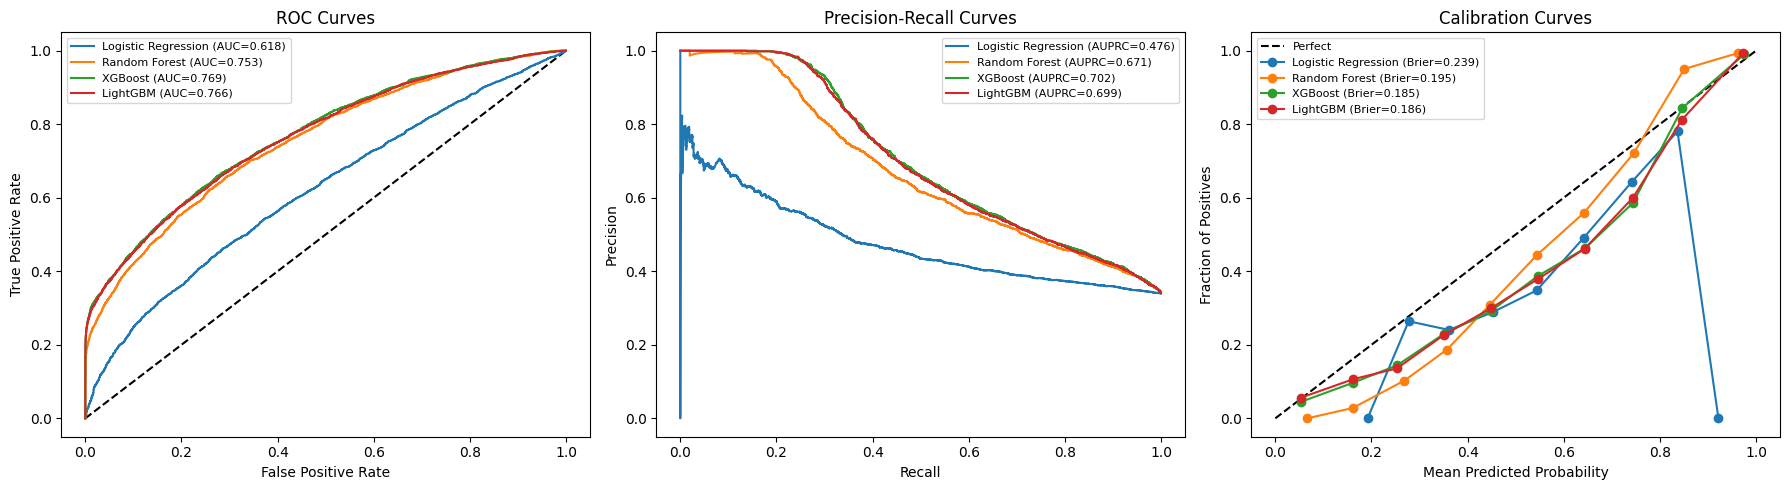

Saved all_curves.png


In [90]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ROC
ax = axes[0]
ax.plot([0,1],[0,1],'k--')
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    ax.plot(fpr, tpr, label=f"{name} (AUC={res['auroc']:.3f})")
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves')
ax.legend(fontsize=8)

# PR
ax = axes[1]
for name, res in results.items():
    auprc = average_precision_score(y_test, res['y_prob'])
    prec, rec, _ = precision_recall_curve(y_test, res['y_prob'])
    ax.plot(rec, prec, label=f"{name} (AUPRC={auprc:.3f})")
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves')
ax.legend(fontsize=8)

# Calibration
ax = axes[2]
ax.plot([0,1],[0,1],'k--', label='Perfect')
for name, res in results.items():
    prob_true, prob_pred = calibration_curve(y_test, res['y_prob'], n_bins=10)
    brier = brier_score_loss(y_test, res['y_prob'])
    ax.plot(prob_pred, prob_true, marker='o',
            label=f"{name} (Brier={brier:.3f})")
ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Fraction of Positives')
ax.set_title('Calibration Curves')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('all_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved all_curves.png")

In [91]:
rows = []
np.random.seed(42)

for name, res in results.items():
    boot = []
    for _ in range(500):
        idx = np.random.choice(len(y_test), len(y_test), replace=True)
        if len(np.unique(y_test.iloc[idx])) < 2:
            continue
        boot.append(roc_auc_score(y_test.iloc[idx], res['y_prob'][idx]))
    lo, hi = np.percentile(boot, [2.5, 97.5])

    rows.append({
        'Model':       name,
        'AUROC':       round(res['auroc'], 3),
        '95% CI':      f"[{lo:.3f}, {hi:.3f}]",
        'AUPRC':       round(average_precision_score(y_test, res['y_prob']), 3),
        'Brier':       round(brier_score_loss(y_test, res['y_prob']), 3),
        'Sensitivity': round(recall_score(y_test, res['y_pred'], zero_division=0), 3),
        'Precision':   round(precision_score(y_test, res['y_pred'], zero_division=0), 3),
        'F1':          round(f1_score(y_test, res['y_pred'], zero_division=0), 3),
        'Threshold':   round(res['threshold'], 2)
    })

comparison_df = pd.DataFrame(rows).sort_values('AUROC', ascending=False)
print("\nFinal Model Comparison Table:")
print(comparison_df.to_string(index=False))


Final Model Comparison Table:
              Model  AUROC         95% CI  AUPRC  Brier  Sensitivity  Precision    F1  Threshold
            XGBoost  0.769 [0.759, 0.778]  0.702  0.185        0.699      0.523 0.598       0.45
           LightGBM  0.766 [0.757, 0.775]  0.699  0.186        0.698      0.525 0.599       0.45
      Random Forest  0.753 [0.743, 0.763]  0.671  0.195        0.681      0.522 0.591       0.45
Logistic Regression  0.618 [0.607, 0.628]  0.476  0.239        0.867      0.363 0.512       0.40


Best model: XGBoost
Using LightGBM for SHAP explainability


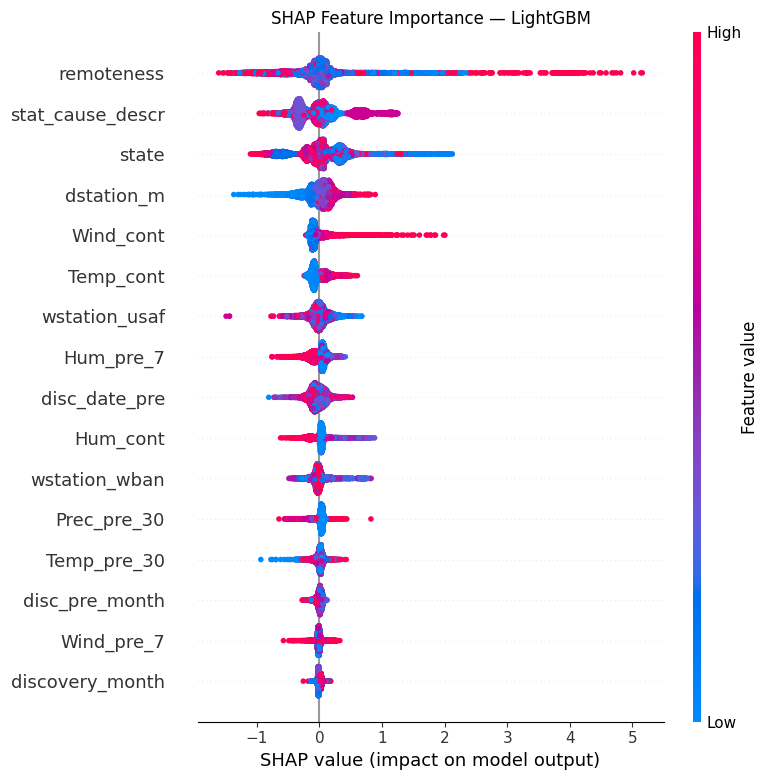

Saved shap_beeswarm.png


In [92]:
best_name  = comparison_df.iloc[0]['Model']
best_model = results[best_name]['model']
print(f"Best model: {best_name}")


tree_models = ['LightGBM', 'XGBoost', 'Random Forest']
shap_model_name = None
for name in tree_models:
    if name in results:
        shap_model_name = name
        break

shap_model = results[shap_model_name]['model']
print(f"Using {shap_model_name} for SHAP explainability")

explainer   = shap.TreeExplainer(shap_model)
shap_values = explainer.shap_values(X_test)

if isinstance(shap_values, list):
    sv = shap_values[1]
elif shap_values.ndim == 3:
    sv = shap_values[:, :, 1]
else:
    sv = shap_values

plt.figure(figsize=(10, 7))
shap.summary_plot(sv, X_test.values, feature_names=FINAL_FEATURES,
                  plot_type='dot', show=False)
plt.title(f'SHAP Feature Importance — {shap_model_name}')
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved shap_beeswarm.png")